## 📊 Project Context

### The Fragmented Market Challenge
In modern European equity markets, liquidity is fragmented across multiple venues:
- **Primary Exchange**: BME (Bolsas y Mercados Españoles)
- **MTFs**: CBOE, Turquoise, Aquis
- **Challenge**: Same ISIN trades simultaneously with price discrepancies
- **Opportunity**: Temporary arbitrage windows due to latency differences

### The Mission
As Quantitative Researchers, we address three critical questions:
1. **Do arbitrage opportunities exist** in Spanish equities?
2. **What is the maximum theoretical profit** (0 latency scenario)?
3. **How does profit decay** with increasing execution latency (0μs → 100ms)?


## 1. Setup & Configuration

In [232]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib

You should consider upgrading via the 'C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\Modulo 2 Introduccion a los Sistemas Financieros\Tareas\Renta Variable\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\Modulo 2 Introduccion a los Sistemas Financieros\Tareas\Renta Variable\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\Modulo 2 Introduccion a los Sistemas Financieros\Tareas\Renta Variable\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'C:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\Modulo 2 Introduccion a los Sistemas Financieros\Tareas\Renta Variable\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [233]:
# Import libraries
import pandas as pd
import numpy as np
import os
import glob
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
import time  # For performance monitoring

# Configuration
DATA_PATH = Path.cwd().parent
DATA_PATH = DATA_PATH / 'DATA_BIG'

# Critical vendor specifications
MAGIC_NUMBERS = [666666.666, 999999.999, 999999.989, 999999.988, 999999.979, 999999.123]

CONTINUOUS_TRADING_CODES = {
    'AQUIS': [5308427],
    'BME': [5832713, 5832756], 
    'CBOE': [12255233],
    'TURQUOISE': [7608181]
}

# Full latency scenarios as specified
LATENCY_SCENARIOS = [0, 100, 500, 1000, 2000, 3000, 4000, 5000, 10000, 15000, 20000, 30000, 50000, 100000]

# Set pandas options for performance
pd.set_option('mode.chained_assignment', None)  # Suppress warnings
pd.set_option('compute.use_bottleneck', True)    # Use bottleneck for speed
pd.set_option('compute.use_numexpr', True)       # Use numexpr for speed

print("✅ Setup complete - Ready for arbitrage analysis")
print(f"📁 Data path: {DATA_PATH}")
print(f"⚡ Latency scenarios: {len(LATENCY_SCENARIOS)} levels")
print(f"🚀 Performance optimizations enabled")

✅ Setup complete - Ready for arbitrage analysis
📁 Data path: c:\Users\piett\OneDrive\Desktop\Pietro\Master MIAX\Clases\Modulo 2 Introduccion a los Sistemas Financieros\Tareas\Renta Variable\DATA_BIG
⚡ Latency scenarios: 14 levels
🚀 Performance optimizations enabled


## 2. Data Ingestion & Cleaning Functions

In [234]:
def get_venue_from_mic(mic: str) -> str:
    """Map MIC codes to venue names"""
    venue_mapping = {
        'XMAD': 'BME',
        'AQEU': 'AQUIS', 
        'CEUX': 'CBOE',
        'TQEX': 'TURQUOISE'
    }
    return venue_mapping.get(mic, mic)

def is_valid_price(price: float) -> bool:
    """Check if price is valid (not a magic number)"""
    if pd.isna(price) or price <= 0:
        return False
    return not any(abs(price - magic) < 0.001 for magic in MAGIC_NUMBERS)

def is_continuous_trading(venue: str, status_code: int) -> bool:
    """Check if venue is in continuous trading mode"""
    return status_code in CONTINUOUS_TRADING_CODES.get(venue, [])

def load_venue_data(data_path: str, isin: str, venue: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load QTE and STS files for a specific ISIN and venue - OPTIMIZED"""
    # Map venue names to folder names
    venue_folders = {
        'BME': 'BME_2025-11-07',
        'AQUIS': 'AQUIS_2025-11-07', 
        'CBOE': 'CBOE_2025-11-07',
        'TURQUOISE': 'TURQUOISE_2025-11-07'
    }
    
    venue_folder = venue_folders.get(venue, f"{venue}_2025-11-07")
    venue_path = os.path.join(data_path, venue_folder)
    
    # More flexible file patterns
    qte_pattern = os.path.join(venue_path, f"QTE_*{isin}*.csv.gz")
    sts_pattern = os.path.join(venue_path, f"STS_*{isin}*.csv.gz")
    
    qte_files = glob.glob(qte_pattern)
    sts_files = glob.glob(sts_pattern)
    
    # Pre-allocate lists for better performance
    qte_dfs = []
    sts_dfs = []
    
    # Optimized QTE loading with chunked reading
    for file in qte_files:
        try:
            with gzip.open(file, 'rt') as f:
                # Read with specific dtypes to reduce memory usage
                df = pd.read_csv(f, sep=';')
                if not df.empty:
                    qte_dfs.append(df)
        except Exception as e:
            print(f"⚠️ Error loading QTE file {file}: {e}")
            continue  # Skip problematic files
    
    # Optimized STS loading
    for file in sts_files:
        try:
            with gzip.open(file, 'rt') as f:
                df = pd.read_csv(f, sep=';',
                                usecols=['epoch', 'market_trading_status'])
                if not df.empty:
                    sts_dfs.append(df)
        except Exception as e:
            print(f"⚠️ Error loading STS file {file}: {e}")
            continue  # Skip problematic files
    
    # Efficient concatenation
    qte_data = pd.concat(qte_dfs, ignore_index=True, copy=False) if qte_dfs else pd.DataFrame()
    sts_data = pd.concat(sts_dfs, ignore_index=True, copy=False) if sts_dfs else pd.DataFrame()
    
    return qte_data, sts_data

def clean_market_data(qte_data: pd.DataFrame, sts_data: pd.DataFrame, venue: str) -> pd.DataFrame:
    """Clean and filter market data according to vendor specifications"""
    if qte_data.empty:
        print(f"⚠️ No QTE data for {venue}")
        return pd.DataFrame()
    
    try:
        # Convert epoch to datetime
        qte_data['timestamp'] = pd.to_datetime(qte_data['epoch'], unit='us')
        
        # Filter valid prices
        if 'px_bid_0' in qte_data.columns and 'px_ask_0' in qte_data.columns:
            # Create magic number mask efficiently
            magic_mask_bid = ~qte_data['px_bid_0'].isin(MAGIC_NUMBERS)
            magic_mask_ask = ~qte_data['px_ask_0'].isin(MAGIC_NUMBERS)
            
            valid_mask = (
                (qte_data['px_bid_0'] > 0) & 
                (qte_data['px_ask_0'] > 0) & 
                qte_data['px_bid_0'].notna() & 
                qte_data['px_ask_0'].notna() &
                magic_mask_bid & magic_mask_ask
            )
            
            qte_data = qte_data[valid_mask].copy()
        
        # Merge with trading status if available
        if not sts_data.empty:
            try:
                sts_data['timestamp'] = pd.to_datetime(sts_data['epoch'], unit='us')
                
                # Sort once for efficiency and merge
                qte_sorted = qte_data.sort_values('timestamp')
                sts_sorted = sts_data.sort_values('timestamp')
                
                # Merge on timestamp (forward fill status)
                merged = pd.merge_asof(
                    qte_sorted,
                    sts_sorted,
                    on='timestamp',
                    direction='backward'
                )
                
                # Filter by continuous trading status
                if 'market_trading_status' in merged.columns:
                    continuous_mask = merged['market_trading_status'].apply(
                        lambda x: is_continuous_trading(venue, x) if pd.notna(x) else False
                    )
                    merged = merged[continuous_mask].copy()
                
                return merged
                
            except Exception as e:
                print(f"⚠️ Error merging STS data for {venue}: {e}")
                return qte_data
        
        return qte_data
        
    except Exception as e:
        print(f"❌ Error cleaning market data for {venue}: {e}")
        return pd.DataFrame()

print("✅ Data ingestion and cleaning functions ready")

✅ Data ingestion and cleaning functions ready


## 3. Consolidated Tape Creation

In [235]:
def create_consolidated_tape(isin: str) -> pd.DataFrame:
    """Create consolidated tape for all venues - HEAVILY OPTIMIZED"""
    data_path = DATA_PATH
    venues = ['BME', 'AQUIS', 'CBOE', 'TURQUOISE']
    
    print(f"📊 Loading data for {isin} (optimized)...")
    
    # Load all venue data in parallel-like structure
    venue_data = {}
    total_records = 0
    
    for venue in venues:
        try:
            qte_data, sts_data = load_venue_data(data_path, isin, venue)
            
            if not qte_data.empty:
                cleaned_data = clean_market_data(qte_data, sts_data, venue)
                
                # Ensure cleaned_data is a DataFrame and not None
                if cleaned_data is not None and not cleaned_data.empty:
                    # Keep only essential columns to reduce memory
                    essential_cols = ['timestamp', 'px_bid_0', 'px_ask_0', 'qty_bid_0', 'qty_ask_0']
                    available_cols = [col for col in essential_cols if col in cleaned_data.columns]
                    
                    if available_cols:  # Only add if we have some columns
                        venue_data[venue] = cleaned_data[available_cols].copy()
                        total_records += len(venue_data[venue])
                        print(f"   ✅ {venue}: {len(venue_data[venue]):,} records loaded")
                    else:
                        print(f"   ⚠️ {venue}: No essential columns found")
                else:
                    print(f"   ⚠️ {venue}: No valid data after cleaning")
            else:
                print(f"   ⚠️ {venue}: No raw data available")
                
        except Exception as e:
            print(f"   ❌ {venue}: Error loading data - {e}")
            continue
    
    if not venue_data:
        print(f"⚠️ No valid data found for {isin}")
        return pd.DataFrame()
    
    print(f"🔧 Building optimized consolidated tape ({total_records:,} total records)...")
    
    try:
        # OPTIMIZED APPROACH: Use resampling with unique timestamps
        all_data = []
        
        for venue, data in venue_data.items():
            # Add venue prefix to columns
            data_copy = data.copy()
            
            # Create venue-specific columns
            venue_columns = {}
            for col in ['px_bid_0', 'px_ask_0', 'qty_bid_0', 'qty_ask_0']:
                if col in data_copy.columns:
                    venue_columns[f"{venue}_{col}"] = data_copy[col]
            
            # Create new DataFrame with venue columns and timestamp
            if venue_columns and 'timestamp' in data_copy.columns:
                venue_df = pd.DataFrame(venue_columns)
                venue_df['timestamp'] = data_copy['timestamp']
                
                # Remove duplicates and sort by timestamp
                venue_df = venue_df.drop_duplicates(subset=['timestamp']).sort_values('timestamp')
                
                # Set timestamp as index
                venue_df.set_index('timestamp', inplace=True)
                all_data.append(venue_df)
        
        # Efficient concatenation with outer join
        if all_data:
            # Use outer join to combine all venues
            consolidated = pd.concat(all_data, axis=1, join='outer', sort=True)
            
            # Forward fill for missing values (more efficient than complex merging)
            consolidated = consolidated.sort_index().ffill()
            
            print(f"✅ Optimized consolidated tape: {len(consolidated):,} timestamps, {len(consolidated.columns)} columns")
            return consolidated
        else:
            print("⚠️ No data available for concatenation")
            return pd.DataFrame()
            
    except Exception as e:
        print(f"❌ Error building consolidated tape: {e}")
        import traceback
        traceback.print_exc()
        return pd.DataFrame()

print("✅ Consolidated tape functions ready")

✅ Consolidated tape functions ready


## 4. Arbitrage Detection Engine

In [236]:
def validate_arbitrage_conditions(row: pd.Series, venues: List[str]) -> Dict:
    """Validate comprehensive arbitrage conditions
    
    Args:
        row: DataFrame row with market data
        venues: List of venue names
        
    Returns:
        Dictionary with validation results and extracted data
    """
    validation = {
        'is_valid': False,
        'sell_venue': None,
        'buy_venue': None,
        'sell_price': None,
        'buy_price': None,
        'tradeable_qty': 0,
        'reason': 'Unknown error'
    }
    
    try:
        # Get max bid and min ask venues
        sell_venue = row.get('Max_Bid_Venue')
        buy_venue = row.get('Min_Ask_Venue')
        
        if pd.isna(sell_venue) or pd.isna(buy_venue):
            validation['reason'] = 'Missing venue information'
            return validation
            
        if sell_venue == buy_venue:
            validation['reason'] = 'Same venue for bid and ask'
            return validation
            
        # Get prices
        sell_price = row.get('Max_Bid')
        buy_price = row.get('Min_Ask')
        
        if pd.isna(sell_price) or pd.isna(buy_price):
            validation['reason'] = 'Missing price information'
            return validation
            
        if sell_price <= buy_price:
            validation['reason'] = f'No arbitrage: sell {sell_price} <= buy {buy_price}'
            return validation
            
        # Get quantities for specific venues
        sell_qty_col = f"{sell_venue}_qty_bid_0"
        buy_qty_col = f"{buy_venue}_qty_ask_0"
        
        sell_qty = row.get(sell_qty_col, 0)
        buy_qty = row.get(buy_qty_col, 0)
        
        if pd.isna(sell_qty) or pd.isna(buy_qty):
            validation['reason'] = 'Missing quantity information'
            return validation
            
        if sell_qty <= 0 or buy_qty <= 0:
            validation['reason'] = f'Invalid quantities: sell={sell_qty}, buy={buy_qty}'
            return validation
            
        # Calculate tradeable quantity
        tradeable_qty = min(int(sell_qty), int(buy_qty))
        
        if tradeable_qty <= 0:
            validation['reason'] = 'No tradeable quantity available'
            return validation
            
        # Check if prices are magic numbers (invalid)
        if sell_price in MAGIC_NUMBERS or buy_price in MAGIC_NUMBERS:
            validation['reason'] = 'Magic number detected in prices'
            return validation
            
        # All validations passed
        validation.update({
            'is_valid': True,
            'sell_venue': sell_venue,
            'buy_venue': buy_venue,
            'sell_price': sell_price,
            'buy_price': buy_price,
            'tradeable_qty': tradeable_qty,
            'reason': 'Valid arbitrage opportunity'
        })
        
    except Exception as e:
        validation['reason'] = f'Validation error: {str(e)}'
        
    return validation

print("✅ Arbitrage validation functions ready")

✅ Arbitrage validation functions ready


In [237]:
def detect_arbitrage_opportunities(consolidated_tape: pd.DataFrame) -> List[Dict]:
    """
    OPTIMIZED Arbitrage Detection Engine - VALIDATED SIGNAL GENERATION
    
    Specifications Implementation:
    • Arbitrage Condition: Global Max Bid > Global Min Ask ✅
    • Profit Calc: (Max Bid - Min Ask) * Min(BidQty, AskQty) ✅
    • Best Prices Only: Uses level 0 bid/ask from all venues ✅
    • Optimized: Fully vectorized numpy operations ✅
    """
    if consolidated_tape.empty:
        return []
    
    venues = ['BME', 'AQUIS', 'CBOE', 'TURQUOISE']
    print(f"🔍 OPTIMIZED signal scanning {len(consolidated_tape):,} timestamps...")
    
    df = consolidated_tape.copy()
    
    # Get available bid/ask columns (level 0 only)
    bid_cols = [f"{venue}_px_bid_0" for venue in venues if f"{venue}_px_bid_0" in df.columns]
    ask_cols = [f"{venue}_px_ask_0" for venue in venues if f"{venue}_px_ask_0" in df.columns]
    
    if len(bid_cols) < 2 or len(ask_cols) < 2:
        print(f"❌ Insufficient venues: {len(bid_cols)} bid, {len(ask_cols)} ask")
        return []
    
    print(f"📊 Scanning {len(bid_cols)} bid venues × {len(ask_cols)} ask venues")
    
    # STEP 1: VECTORIZED GLOBAL MAX/MIN CALCULATION
    # Convert to numpy arrays for speed
    bid_values = df[bid_cols].values  # Shape: (timestamps, venues)
    ask_values = df[ask_cols].values  # Shape: (timestamps, venues)
    
    # Find GLOBAL max bid and GLOBAL min ask for each timestamp
    global_max_bid_indices = np.nanargmax(bid_values, axis=1)
    global_min_ask_indices = np.nanargmin(ask_values, axis=1)
    
    global_max_bids = bid_values[np.arange(len(bid_values)), global_max_bid_indices]
    global_min_asks = ask_values[np.arange(len(ask_values)), global_min_ask_indices]
    
    # Get venue names
    bid_venue_names = [col.replace('_px_bid_0', '') for col in bid_cols]
    ask_venue_names = [col.replace('_px_ask_0', '') for col in ask_cols]
    
    max_bid_venues = [bid_venue_names[i] for i in global_max_bid_indices]
    min_ask_venues = [ask_venue_names[i] for i in global_min_ask_indices]
    
    # STEP 2: ARBITRAGE CONDITION VALIDATION
    # Arbitrage exists when: Global Max Bid > Global Min Ask
    arbitrage_mask = (
        (global_max_bids > global_min_asks) &  # Core arbitrage condition ✅
        (~np.isnan(global_max_bids)) &         # Valid bid prices
        (~np.isnan(global_min_asks)) &         # Valid ask prices
        (global_max_bids > 0) &                # Positive bid prices
        (global_min_asks > 0) &                # Positive ask prices
        (np.array(max_bid_venues) != np.array(min_ask_venues))  # Different venues ✅
    )
    
    arbitrage_indices = np.where(arbitrage_mask)[0]
    print(f"💡 Found {len(arbitrage_indices):,} VALID arbitrage signals")
    
    if len(arbitrage_indices) == 0:
        return []
    
    # STEP 3: PROFIT CALCULATION & QUANTITY VALIDATION
    opportunities = []
    timestamps = df.index.values
    
    for idx in arbitrage_indices:
        sell_venue = max_bid_venues[idx]  # Where we sell (highest bid)
        buy_venue = min_ask_venues[idx]   # Where we buy (lowest ask)
        sell_price = global_max_bids[idx] # Global max bid price
        buy_price = global_min_asks[idx]  # Global min ask price
        
        # Get quantities for exact venues
        sell_qty_col = f"{sell_venue}_qty_bid_0"
        buy_qty_col = f"{buy_venue}_qty_ask_0"
        
        if sell_qty_col in df.columns and buy_qty_col in df.columns:
            bid_qty = df.iloc[idx][sell_qty_col]  # Available at sell venue
            ask_qty = df.iloc[idx][buy_qty_col]   # Available at buy venue
            
            if pd.notna(bid_qty) and pd.notna(ask_qty) and bid_qty > 0 and ask_qty > 0:
                # VALIDATED PROFIT CALCULATION: Min(BidQty, AskQty) ✅
                tradeable_quantity = min(int(bid_qty), int(ask_qty))
                
                if tradeable_quantity > 0:
                    profit_per_share = sell_price - buy_price  # (Max Bid - Min Ask) ✅
                    total_profit = profit_per_share * tradeable_quantity  # × Min(BidQty, AskQty) ✅
                    
                    opportunity = {
                        'timestamp': pd.Timestamp(timestamps[idx]),
                        'buy_venue': buy_venue,
                        'sell_venue': sell_venue,
                        'buy_price': buy_price,
                        'sell_price': sell_price,
                        'buy_level': 0,    # Best ask level
                        'sell_level': 0,   # Best bid level
                        'quantity': tradeable_quantity,
                        'profit_per_share': profit_per_share,
                        'total_profit': total_profit,
                        'profit_bps': (profit_per_share / buy_price) * 10000,
                        'global_max_bid': sell_price,
                        'global_min_ask': buy_price
                    }
                    opportunities.append(opportunity)
    
    print(f"✅ Signal generation complete: {len(opportunities):,} profitable opportunities")
    
    if opportunities:
        total_profit = sum(opp['total_profit'] for opp in opportunities)
        avg_profit_bps = np.mean([opp['profit_bps'] for opp in opportunities])
        print(f"📊 Total theoretical profit: €{total_profit:.2f}")
        print(f"📈 Average spread: {avg_profit_bps:.2f} basis points")
    
    return opportunities

def deduplicate_opportunities_rising_edge(opportunities: List[Dict], time_window_us: int = 1000000) -> List[Dict]:
    """
    VALIDATED Rising Edge Detection - Prevents Double Counting
    
    Specification Implementation:
    • Rising Edge: Only count first occurrence within 1 second (1000000μs) ✅
    • No Double Counting: Same signal ignored within time window ✅
    • New Opportunity: If signal vanishes and reappears, count as new ✅
    """
    if not opportunities:
        return []
    
    print(f"🔄 Applying VALIDATED Rising Edge (window: {time_window_us/1000:.0f}ms = 1 second)")
    
    # Sort by timestamp
    sorted_opps = sorted(opportunities, key=lambda x: x['timestamp'])
    deduplicated = []
    
    current_signal = None
    signal_start_time = None
    
    for opp in sorted_opps:
        # OPTIMIZED Signal Identity: Only essential components
        # Exclude price values to avoid false duplicates from tiny price movements
        signal_id = (
            opp['buy_venue'],   # Which venue to buy from
            opp['sell_venue']   # Which venue to sell to
            # NOTE: Removed price levels to allow for small price fluctuations
        )
        
        if current_signal is None:
            # First opportunity ever
            current_signal = signal_id
            signal_start_time = opp['timestamp']
            deduplicated.append(opp)
            
        elif signal_id == current_signal:
            # Same signal (same venue pair)
            time_diff = opp['timestamp'] - signal_start_time
            time_diff_us = time_diff.total_seconds() * 1e6
            
            if time_diff_us < time_window_us:
                # Within 1 second window - SKIP (prevent double counting) ✅
                continue
            else:
                # Beyond 1 second - Count as NEW opportunity ✅
                signal_start_time = opp['timestamp']
                deduplicated.append(opp)
        else:
            # Different signal (new venue pair) - Always count ✅
            current_signal = signal_id    
            signal_start_time = opp['timestamp']
            deduplicated.append(opp)
    
    reduction = len(opportunities) - len(deduplicated)
    reduction_pct = (reduction / len(opportunities)) * 100 if opportunities else 0
    
    print(f"📊 {len(opportunities):,} → {len(deduplicated):,} opportunities")
    print(f"🚫 {reduction:,} duplicate signals removed ({reduction_pct:.1f}% reduction)")
    
    return deduplicated

# Legacy function name for compatibility
def deduplicate_opportunities(opportunities: List[Dict], time_window_us: int = 1000000) -> List[Dict]:
    """Legacy wrapper - calls optimized rising edge function"""
    return deduplicate_opportunities_rising_edge(opportunities, time_window_us)

print("✅ VALIDATED Arbitrage detection engine ready")


✅ VALIDATED Arbitrage detection engine ready


## 5. Latency Simulation - The Time Machine

In [238]:
def simulate_latency_impact(opportunities: List[Dict], consolidated_tape: pd.DataFrame, latency_us: int) -> Dict:
    """
    CORRECTED Time Machine Simulation - Models Reality of Trading Latency
    
    Reality: If you see a price at time T, you cannot trade until T + Δ (latency)
    Method: Look up actual profit at T + Latency in the consolidated tape
    
    Expected Behavior: More latency → Less arbitrage opportunities (prices move against us)
    """
    if latency_us == 0:
        # Zero latency - theoretical maximum (instantaneous execution)
        total_profit = sum(opp['total_profit'] for opp in opportunities)
        return {
            'latency_us': latency_us,
            'latency_ms': 0.0,
            'total_profit': total_profit,
            'executed_opportunities': len(opportunities),
            'success_rate': 1.0,
            'avg_profit_per_opp': total_profit / len(opportunities) if opportunities else 0
        }
    
    if not opportunities or consolidated_tape.empty:
        return {
            'latency_us': latency_us,
            'latency_ms': latency_us / 1000.0,
            'total_profit': 0.0,
            'executed_opportunities': 0,
            'success_rate': 0.0,
            'avg_profit_per_opp': 0.0
        }
    
    executed_profit = 0.0
    executed_count = 0
    
    # Convert latency to pandas Timedelta for precise time arithmetic
    latency_delta = pd.Timedelta(microseconds=latency_us)
    
    # Ensure consolidated tape index is datetime
    if not isinstance(consolidated_tape.index, pd.DatetimeIndex):
        print(f"⚠️  Warning: Consolidated tape index is not datetime")
        return {
            'latency_us': latency_us,
            'latency_ms': latency_us / 1000.0,
            'total_profit': 0.0,
            'executed_opportunities': 0,
            'success_rate': 0.0,
            'avg_profit_per_opp': 0.0
        }
    
    # Process each arbitrage opportunity
    for opp in opportunities:
        try:
            # STEP 1: Signal detected at time T
            signal_time = pd.Timestamp(opp['timestamp'])
            
            # STEP 2: Execution attempted at T + Δ (latency)
            execution_time = signal_time + latency_delta
            
            # STEP 3: Find market state at execution time using time machine
            tape_index = consolidated_tape.index
            
            # Find the first timestamp >= execution_time
            idx = tape_index.searchsorted(execution_time, side='left')
            
            # Check if we have data at execution time
            if idx >= len(tape_index):
                # No future data available - opportunity lost
                continue
            
            # STEP 4: Get actual market prices at execution time T + Δ
            future_row = consolidated_tape.iloc[idx]
            actual_execution_time = tape_index[idx]
            
            # Extract original trade details
            buy_venue = opp['buy_venue']
            sell_venue = opp['sell_venue']
            original_quantity = opp['quantity']
            
            # Column names for market data at execution time
            buy_price_col = f"{buy_venue}_px_ask_0"  # We buy at ask price
            sell_price_col = f"{sell_venue}_px_bid_0"  # We sell at bid price
            buy_qty_col = f"{buy_venue}_qty_ask_0"
            sell_qty_col = f"{sell_venue}_qty_bid_0"
            
            # STEP 5: Get actual prices at execution time
            actual_buy_price = future_row.get(buy_price_col, np.nan)
            actual_sell_price = future_row.get(sell_price_col, np.nan)
            
            # STEP 6: Validate prices are available and valid
            if pd.isna(actual_buy_price) or pd.isna(actual_sell_price):
                # Missing price data at execution time
                continue
                
            if actual_buy_price <= 0 or actual_sell_price <= 0:
                # Invalid prices
                continue
            
            # STEP 7: Check if arbitrage still exists at T + Δ
            if actual_sell_price <= actual_buy_price:
                # Arbitrage disappeared - prices moved against us
                continue
            
            # STEP 8: Get available quantities at execution time
            actual_buy_qty = future_row.get(buy_qty_col, original_quantity)
            actual_sell_qty = future_row.get(sell_qty_col, original_quantity)
            
            if pd.isna(actual_buy_qty) or pd.isna(actual_sell_qty):
                # Use original quantity if no qty data available
                actual_buy_qty = original_quantity
                actual_sell_qty = original_quantity
            
            # STEP 9: Calculate executable quantity
            executable_quantity = min(
                abs(int(actual_buy_qty)) if pd.notna(actual_buy_qty) and actual_buy_qty > 0 else original_quantity,
                abs(int(actual_sell_qty)) if pd.notna(actual_sell_qty) and actual_sell_qty > 0 else original_quantity,
                original_quantity  # Can't trade more than original opportunity
            )
            
            if executable_quantity <= 0:
                continue
            
            # STEP 10: Calculate REALIZED profit at T + Δ
            profit_per_share = actual_sell_price - actual_buy_price
            total_opportunity_profit = profit_per_share * executable_quantity
            
            if total_opportunity_profit > 0:
                executed_profit += total_opportunity_profit
                executed_count += 1
                
        except Exception as e:
            # Skip opportunity if any error occurs during time machine simulation
            continue
    
    # Calculate performance metrics
    success_rate = executed_count / len(opportunities) if opportunities else 0.0
    avg_profit_per_opp = executed_profit / executed_count if executed_count > 0 else 0.0
    
    return {
        'latency_us': latency_us,
        'latency_ms': latency_us / 1000.0,
        'total_profit': executed_profit,
        'executed_opportunities': executed_count,
        'success_rate': success_rate,
        'avg_profit_per_opp': avg_profit_per_opp
    }

def run_latency_analysis(opportunities: List[Dict], consolidated_tape: pd.DataFrame) -> pd.DataFrame:
    """
    Run COMPLETE Time Machine Analysis Across All Required Latency Scenarios
    
    Required latencies: [0, 100, 500, 1000, 2000, 3000, 4000, 5000, 10000, 15000, 20000, 30000, 50000, 100000] microseconds
    """
    # Ensure we test ALL required latency scenarios
    REQUIRED_LATENCIES = [0, 100, 500, 1000, 2000, 3000, 4000, 5000, 10000, 15000, 20000, 30000, 50000, 100000]
    
    print(f"⏱️  TIME MACHINE ANALYSIS - Testing Trading Reality")
    print(f"📊 Opportunities: {len(opportunities)}")
    print(f"📈 Tape timestamps: {len(consolidated_tape):,}")
    print(f"🎯 Latency scenarios: {len(REQUIRED_LATENCIES)} levels")
    print(f"💡 Expected: MORE latency = FEWER profitable opportunities")
    print()
    
    results = []
    baseline_profit = 0.0
    
    for i, latency_us in enumerate(REQUIRED_LATENCIES):
        latency_ms = latency_us / 1000.0
        
        # Run time machine simulation
        result = simulate_latency_impact(opportunities, consolidated_tape, latency_us)
        results.append(result)
        
        if latency_us == 0:
            baseline_profit = result['total_profit']
            print(f"  🏆 {latency_us:6d}μs ({latency_ms:6.1f}ms): €{result['total_profit']:8.4f} | Success: {result['success_rate']:5.1%} | Executed: {result['executed_opportunities']:3d} (THEORETICAL MAX)")
        else:
            profit_loss_pct = ((baseline_profit - result['total_profit']) / baseline_profit * 100) if baseline_profit > 0 else 0
            print(f"  ⚡ {latency_us:6d}μs ({latency_ms:6.1f}ms): €{result['total_profit']:8.4f} | Success: {result['success_rate']:5.1%} | Executed: {result['executed_opportunities']:3d} | Loss: {profit_loss_pct:5.1f}%")
    
    # Summary analysis
    results_df = pd.DataFrame(results)
    final_profit = results_df.iloc[-1]['total_profit'] if len(results_df) > 0 else 0
    total_loss_pct = ((baseline_profit - final_profit) / baseline_profit * 100) if baseline_profit > 0 else 0
    
    print(f"\n📊 TIME MACHINE SUMMARY:")
    print(f"  🎯 Theoretical Maximum (0μs): €{baseline_profit:.4f}")
    print(f"  ⚡ Final Reality (100ms): €{final_profit:.4f}")
    print(f"  📉 Total Latency Impact: {total_loss_pct:.1f}% profit lost")
    print(f"  ✅ Time machine simulation: COMPLETE")
    
    return results_df

print("✅ CORRECTED Time Machine ready - Models trading reality accurately")

✅ CORRECTED Time Machine ready - Models trading reality accurately


In [239]:
# 🧪 TIME MACHINE DEBUGGING - Let's test the latency simulation
print("🔍 DEBUGGING TIME MACHINE LATENCY SIMULATION")
print("=" * 60)

# Test the logic with existing data
if 'analysis_results' in locals() and analysis_results:
    # Get first successful result for testing
    test_result = None
    for isin, result in analysis_results.items():
        if result['status'] == 'success' and result['opportunities']:
            test_result = result
            test_isin = isin
            break
    
    if test_result:
        print(f"🎯 Testing with {test_isin}")
        opportunities = test_result['opportunities'][:5]  # Test with first 5 opportunities
        consolidated_tape = test_result.get('consolidated_tape', pd.DataFrame())
        
        print(f"📊 Test data:")
        print(f"  • Opportunities: {len(opportunities)}")
        print(f"  • Consolidated tape timestamps: {len(consolidated_tape)}")
        
        if not consolidated_tape.empty:
            print(f"  • Tape time range: {consolidated_tape.index.min()} to {consolidated_tape.index.max()}")
        
        # Test specific latency scenarios
        test_latencies = [0, 1000, 10000, 100000]  # 0μs, 1ms, 10ms, 100ms
        
        for latency_us in test_latencies:
            print(f"\n🔬 Testing {latency_us}μs ({latency_us/1000:.1f}ms) latency:")
            
            if latency_us == 0:
                # Zero latency - should be theoretical max
                total_theoretical = sum(opp['total_profit'] for opp in opportunities)
                print(f"  💰 Theoretical profit: €{total_theoretical:.4f}")
            else:
                # Test the time machine logic manually for one opportunity
                opp = opportunities[0]
                signal_time = pd.Timestamp(opp['timestamp'])
                execution_time = signal_time + pd.Timedelta(microseconds=latency_us)
                
                print(f"  📅 Signal detected at: {signal_time}")
                print(f"  ⏰ Execution attempted at: {execution_time}")
                
                if not consolidated_tape.empty:
                    # Check if execution time is within data range
                    if execution_time <= consolidated_tape.index.max():
                        # Find market state at execution time
                        idx = consolidated_tape.index.searchsorted(execution_time, side='left')
                        
                        if idx < len(consolidated_tape):
                            future_row = consolidated_tape.iloc[idx]
                            actual_time = consolidated_tape.index[idx]
                            
                            print(f"  📈 Actual execution at: {actual_time}")
                            print(f"  ⏳ Time difference: {(actual_time - signal_time).total_seconds() * 1e6:.0f}μs")
                            
                            # Check venues and prices
                            buy_venue = opp['buy_venue']
                            sell_venue = opp['sell_venue']
                            
                            ask_col = f"{buy_venue}_px_ask_0"
                            bid_col = f"{sell_venue}_px_bid_0"
                            
                            original_ask = opp['buy_price']
                            original_bid = opp['sell_price']
                            
                            actual_ask = future_row.get(ask_col, np.nan)
                            actual_bid = future_row.get(bid_col, np.nan)
                            
                            print(f"  🏷️  Original: Buy {buy_venue}@{original_ask:.4f}, Sell {sell_venue}@{original_bid:.4f}")
                            print(f"  🏷️  At execution: Buy {buy_venue}@{actual_ask:.4f}, Sell {sell_venue}@{actual_bid:.4f}")
                            
                            if pd.notna(actual_ask) and pd.notna(actual_bid):
                                if actual_bid > actual_ask:
                                    profit = (actual_bid - actual_ask) * opp['quantity']
                                    print(f"  ✅ Arbitrage still exists! Profit: €{profit:.4f}")
                                else:
                                    print(f"  ❌ Arbitrage vanished: {actual_bid:.4f} <= {actual_ask:.4f}")
                            else:
                                print(f"  ⚠️  Missing price data at execution time")
                        else:
                            print(f"  ❌ No market data available at execution time")
                    else:
                        print(f"  ⚠️  Execution time beyond available data")
                else:
                    print(f"  ❌ No consolidated tape available for testing")
        
        # Now run the actual function to compare
        print(f"\n🔧 RUNNING ACTUAL simulate_latency_impact FUNCTION:")
        for latency_us in test_latencies:
            result = simulate_latency_impact(opportunities, consolidated_tape, latency_us)
            print(f"  {latency_us:6d}μs: €{result['total_profit']:8.4f} | Success: {result['success_rate']:5.1%} | Executed: {result['executed_opportunities']}")
    else:
        print("❌ No successful analysis results available for testing")
else:
    print("❌ No analysis results available - run the main analysis first")

🔍 DEBUGGING TIME MACHINE LATENCY SIMULATION
🎯 Testing with ES0105046017
📊 Test data:
  • Opportunities: 5
  • Consolidated tape timestamps: 98058
  • Tape time range: 2025-11-07 08:00:17.042651 to 2025-11-07 16:30:00.572819

🔬 Testing 0μs (0.0ms) latency:
  💰 Theoretical profit: €16.0100

🔬 Testing 1000μs (1.0ms) latency:
  📅 Signal detected at: 2025-11-07 16:02:56.114666
  ⏰ Execution attempted at: 2025-11-07 16:02:56.115666
  📈 Actual execution at: 2025-11-07 16:02:56.117145
  ⏳ Time difference: 2479μs
  🏷️  Original: Buy CBOE@22.0900, Sell BME@22.1000
  🏷️  At execution: Buy CBOE@22.0900, Sell BME@22.1000
  ✅ Arbitrage still exists! Profit: €7.6300

🔬 Testing 10000μs (10.0ms) latency:
  📅 Signal detected at: 2025-11-07 16:02:56.114666
  ⏰ Execution attempted at: 2025-11-07 16:02:56.124666
  📈 Actual execution at: 2025-11-07 16:02:56.124843
  ⏳ Time difference: 10177μs
  🏷️  Original: Buy CBOE@22.0900, Sell BME@22.1000
  🏷️  At execution: Buy CBOE@22.0900, Sell BME@22.1000
  ✅ Arbitr

## 6. Analysis & Results Generation

In [240]:
def analyze_isin(isin: str) -> Dict:
    """Complete arbitrage analysis for a single ISIN"""
    print(f"\n🎯 ANALYZING {isin}")
    print("=" * 50)
    
    # Step 1: Create consolidated tape
    consolidated = create_consolidated_tape(isin)
    
    if consolidated.empty:
        print(f"❌ No data available for {isin}")
        return {
            'isin': isin,
            'opportunities': [],
            'latency_results': pd.DataFrame(),
            'status': 'no_data'
        }
    
    print(f"\n🔍 DETECTING ARBITRAGE OPPORTUNITIES...")
    opportunities = detect_arbitrage_opportunities(consolidated)
    
    if not opportunities:
        print(f"📊 No arbitrage opportunities found for {isin}")
        
        # Check if we have cross-venue data
        venues = ['BME', 'AQUIS', 'CBOE', 'TURQUOISE']
        venues_with_data = []
        for venue in venues:
            bid_col = f"{venue}_px_bid_0"
            if bid_col in consolidated.columns and consolidated[bid_col].notna().any():
                venues_with_data.append(venue)
        
        print(f"💡 Venues with data: {venues_with_data}")
        
        if len(venues_with_data) < 2:
            print("⚠️ Need at least 2 venues for arbitrage detection!")
            
        return {
            'isin': isin,
            'opportunities': [],
            'latency_results': pd.DataFrame(),
            'status': 'no_opportunities'
        }
    
    # Step 2: Deduplicate
    unique_opportunities = deduplicate_opportunities(opportunities)
    
    # Step 3: Latency analysis
    latency_results = run_latency_analysis(unique_opportunities, consolidated)
    
    print(f"✅ Analysis complete for {isin}")
    
    return {
        'isin': isin,
        'opportunities': unique_opportunities,
        'latency_results': latency_results,
        'consolidated_tape': consolidated,
        'status': 'success'
    }

def create_money_table(analysis_results: Dict[str, Dict]) -> pd.DataFrame:
    """Create the Money Table - profit by ISIN and latency"""
    money_data = []
    
    for isin, result in analysis_results.items():
        if result['status'] == 'success' and not result['latency_results'].empty:
            for _, row in result['latency_results'].iterrows():
                money_data.append({
                    'ISIN': isin,
                    'Latency_us': row['latency_us'],
                    'Total_Profit_EUR': row['total_profit'],
                    'Executed_Opportunities': row['executed_opportunities'],
                    'Success_Rate': row['success_rate']
                })
    
    if money_data:
        df = pd.DataFrame(money_data)
        # Pivot for better visualization
        money_table = df.pivot(index='ISIN', columns='Latency_us', values='Total_Profit_EUR')
        return money_table
    
    return pd.DataFrame()

def plot_decay_curve(analysis_results: Dict[str, Dict]):
    """Plot the latency decay curve - MODIFIED to show aggregated data for multiple ISINs"""
    plt.figure(figsize=(12, 8))
    
    # Check if we have multiple ISINs
    successful_results = {isin: result for isin, result in analysis_results.items() 
                         if result['status'] == 'success' and not result['latency_results'].empty}
    
    if len(successful_results) == 1:
        # Single ISIN - show individual line
        for isin, result in successful_results.items():
            data = result['latency_results']
            plt.plot(data['latency_us'], data['total_profit'], 
                    marker='o', label=isin, linewidth=2)
            plt.title(f'Arbitrage Profit Decay vs Latency - {isin}', fontsize=14, fontweight='bold')
    
    else:
        # Multiple ISINs - show AGGREGATED (consolidated) line
        print("📊 Creating consolidated view for multiple ISINs...")
        
        # Calculate aggregated totals by latency
        aggregated_data = {}
        for latency in LATENCY_SCENARIOS:
            total_profit_at_latency = 0
            for result in successful_results.values():
                latency_data = result['latency_results']
                profit_at_latency = latency_data[latency_data['latency_us'] == latency]['total_profit']
                if not profit_at_latency.empty:
                    total_profit_at_latency += profit_at_latency.iloc[0]
            aggregated_data[latency] = total_profit_at_latency

        print(aggregated_data)
        
        # Plot aggregated data
        latencies = list(aggregated_data.keys())
        profits = list(aggregated_data.values())
        
        plt.plot(latencies, profits, marker='o', 
                label=f'Combined ({len(successful_results)} ISINs)', 
                linewidth=3, color='#2E86AB', markersize=8)
        
        plt.title(f'Arbitrage Profit Decay vs Latency - Consolidated View ({len(successful_results)} ISINs)', 
                 fontsize=14, fontweight='bold')
    
    plt.xlabel('Latency (microseconds)', fontsize=12)
    plt.ylabel('Total Profit (EUR)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xscale('log')
    
    # Add annotations
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    plt.text(0.02, 0.98, 'Reality Check: Latency Kills Profit', 
             transform=plt.gca().transAxes, fontsize=10, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
    
    plt.tight_layout()
    plt.show()

print("✅ Analysis functions ready")

✅ Analysis functions ready


## 7. Execute Analysis - Spanish Equities

In [241]:
def discover_available_isins(data_path: str) -> List[str]:
    """Automatically discover all ISINs available in the data folders - OPTIMIZED"""
    venue_folders = ['BME_2025-11-07', 'AQUIS_2025-11-07', 'CBOE_2025-11-07', 'TURQUOISE_2025-11-07']
    all_isins = set()
    
    for venue_folder in venue_folders:
        venue_path = os.path.join(data_path, venue_folder)
        if os.path.exists(venue_path):
            # Fast file pattern matching
            qte_pattern = os.path.join(venue_path, "QTE_*.csv.gz")
            qte_files = glob.glob(qte_pattern)
            
            # Extract ISINs efficiently
            for file in qte_files:
                filename = os.path.basename(file)
                parts = filename.split('_')
                if len(parts) >= 3:
                    potential_isin = parts[2]
                    # Quick ISIN validation
                    if len(potential_isin) == 12 and potential_isin[:2].isalpha():
                        all_isins.add(potential_isin)
    
    return sorted(list(all_isins))

print(f"\n🚀 FAST ARBITRAGE ANALYSIS (OPTIMIZED)")
print("=" * 60)

# CRITICAL: Use the optimized LATENCY_SCENARIOS from setup cell
print(f"⚡ Using optimized latency scenarios: {LATENCY_SCENARIOS}")

# OPTIMIZED CONFIGURATION for speed
# Reduce to fewer ISINs for faster execution
# SPANISH_ISINS = ["ES0177542018"] 

# For testing multiple ISINs (uncomment and modify as needed):
discovered = discover_available_isins(DATA_PATH)

# Filter only spanish isins
discovered = [isin for isin in discovered if isin.startswith('ES')]
SPANISH_ISINS = discovered

# Determine analysis type
IS_SINGLE_ISIN = len(SPANISH_ISINS) == 1
analysis_type = "SINGLE ISIN (OPTIMIZED)" if IS_SINGLE_ISIN else "MULTIPLE ISINs (OPTIMIZED)"

print(f"📋 Analysis Type: {analysis_type}")
print(f"🎯 Target ISINs ({len(SPANISH_ISINS)}): {SPANISH_ISINS}")
print(f"⚡ Latency scenarios: {len(LATENCY_SCENARIOS)} levels (OPTIMIZED)")

# OPTIMIZED: Pre-allocate results dictionary
analysis_results = {}

# Add timing for performance monitoring
import time
start_time = time.time()

# Run analysis for each ISIN with progress tracking
for i, isin in enumerate(SPANISH_ISINS):
    isin_start = time.time()
    print(f"\n🔄 Processing {i+1}/{len(SPANISH_ISINS)}: {isin}")
    
    try:
        result = analyze_isin(isin)
        analysis_results[isin] = result
        
        isin_time = time.time() - isin_start
        print(f"⏱️  ISIN {isin} processed in {isin_time:.2f}s")
        
        if result['status'] == 'success':
            print(f"✅ Found {len(result['opportunities'])} opportunities")
            if result['opportunities']:
                total_profit = sum(opp['total_profit'] for opp in result['opportunities'])
                print(f"💰 Theoretical profit: €{total_profit:.2f}")
        
    except Exception as e:
        print(f"❌ Error analyzing {isin}: {e}")
        analysis_results[isin] = {
            'isin': isin,
            'opportunities': [],
            'latency_results': pd.DataFrame(),
            'status': 'error',
            'error': str(e)
        }

total_time = time.time() - start_time

print(f"\n📊 OPTIMIZED ANALYSIS COMPLETE")
print("=" * 40)
print(f"⏱️  Total execution time: {total_time:.2f} seconds")

# Quick summary statistics
successful_analyses = sum(1 for r in analysis_results.values() if r['status'] == 'success')
total_opportunities = sum(len(r['opportunities']) for r in analysis_results.values())

print(f"✅ Successful analyses: {successful_analyses}/{len(SPANISH_ISINS)}")
print(f"💰 Total opportunities found: {total_opportunities}")

if total_opportunities > 0:
    total_theoretical_profit = sum(
        sum(opp['total_profit'] for opp in r['opportunities'])
        for r in analysis_results.values()
        if r['opportunities']
    )
    print(f"💵 Total theoretical profit (0 latency): €{total_theoretical_profit:.2f}")
    
    # Performance metrics
    if total_time > 0:
        opps_per_second = total_opportunities / total_time
        print(f"⚡ Performance: {opps_per_second:.0f} opportunities/second")
else:
    print("📈 Market appears efficient - no arbitrage opportunities detected")


🚀 FAST ARBITRAGE ANALYSIS (OPTIMIZED)
⚡ Using optimized latency scenarios: [0, 100, 500, 1000, 2000, 3000, 4000, 5000, 10000, 15000, 20000, 30000, 50000, 100000]
📋 Analysis Type: MULTIPLE ISINs (OPTIMIZED)
🎯 Target ISINs (138): ['ES0105025003', 'ES0105027009', 'ES0105029005', 'ES0105043006', 'ES0105046017', 'ES0105065009', 'ES0105066007', 'ES0105079000', 'ES0105089009', 'ES0105093001', 'ES0105102000', 'ES0105121000', 'ES0105122024', 'ES0105130001', 'ES0105148003', 'ES0105223004', 'ES0105225009', 'ES0105229001', 'ES0105251005', 'ES0105287009', 'ES0105321030', 'ES0105336038', 'ES0105375002', 'ES0105449005', 'ES0105456026', 'ES0105463006', 'ES0105509006', 'ES0105517025', 'ES0105521001', 'ES0105546008', 'ES0105548004', 'ES0105563003', 'ES0105589008', 'ES0105606190', 'ES0105611000', 'ES0105618005', 'ES0105621009', 'ES0105630315', 'ES0105634002', 'ES0105650008', 'ES0105691002', 'ES0105702007', 'ES0105709002', 'ES0105716130', 'ES0105717005', 'ES0105725008', 'ES0105777017', 'ES0105836003', 'E

KeyboardInterrupt: 

## 8. Results - The Money Table

In [ ]:
# Create and display the Money Table
print("💰 THE MONEY TABLE")
print("=" * 50)

if IS_SINGLE_ISIN:
    print(f"Total Realized Profit for {SPANISH_ISINS[0]} by Latency (EUR)")
else:
    print("Total Realized Profit by ISIN and Latency (EUR)")
print()

money_table = create_money_table(analysis_results)

if not money_table.empty:
    if IS_SINGLE_ISIN:
        # For single ISIN, show as time series
        if len(money_table) == 1:
            single_isin_data = money_table.iloc[0]
            print("Latency Impact Analysis:")
            print("-" * 40)
            for latency_us, profit in single_isin_data.items():
                latency_ms = latency_us / 1000
                if pd.notna(profit):
                    print(f"  {latency_ms:6.1f}ms: €{profit:8.4f}")
            
            # Impact analysis
            theoretical_max = single_isin_data.iloc[0] if len(single_isin_data) > 0 else 0
            final_profit = single_isin_data.iloc[-1] if len(single_isin_data) > 0 else 0
            if theoretical_max > 0:
                loss_pct = ((theoretical_max - final_profit) / theoretical_max) * 100
                print(f"\n📊 Key Insights:")
                print(f"🏆 Theoretical Maximum (0μs): €{theoretical_max:.4f}")
                print(f"⚡ Final Profit (100ms): €{final_profit:.4f}")
                print(f"📉 Total Profit Loss: {loss_pct:.1f}%")
    else:
        # For multiple ISINs, show complete table and aggregates
        money_table_formatted = money_table.round(4)
        print(money_table_formatted.to_string())
        
        # Calculate aggregated totals
        print("\n🔢 AGGREGATED RESULTS (All ISINs Combined)")
        print("-" * 50)
        total_by_latency = money_table.sum(axis=0, skipna=True)
        for latency_us, total_profit in total_by_latency.items():
            latency_ms = latency_us / 1000
            print(f"  {latency_ms:6.1f}ms: €{total_profit:8.4f}")
        
        print("\n📊 Key Insights:")
        
        # Best performing ISINs at 0 latency
        if 0 in money_table.columns:
            zero_latency = money_table[0].dropna().sort_values(ascending=False)
            if not zero_latency.empty:
                print(f"🏆 Top performer (0 latency): {zero_latency.index[0]} - €{zero_latency.iloc[0]:.2f}")
                if len(zero_latency) > 1:
                    print(f"🥈 Second best: {zero_latency.index[1]} - €{zero_latency.iloc[1]:.2f}")
                if len(zero_latency) > 2:
                    print(f"🥉 Third best: {zero_latency.index[2]} - €{zero_latency.iloc[2]:.2f}")
        
        # Aggregated latency impact
        if len(total_by_latency) > 1:
            total_theoretical = total_by_latency.iloc[0]
            total_final = total_by_latency.iloc[-1]
            if total_theoretical > 0:
                total_loss_pct = ((total_theoretical - total_final) / total_theoretical) * 100
                print(f"⚡ Overall latency impact: {total_loss_pct:.1f}% total profit lost")
else:
    print("❌ No profitable opportunities found")
    print("💡 This suggests:")
    print("   • Market efficiency is high")
    print("   • Arbitrage windows are very brief")
    print("   • Need higher frequency data or different ISINs")

💰 THE MONEY TABLE
Total Realized Profit by ISIN and Latency (EUR)

Latency_us     0.0       100.0     500.0     1000.0    2000.0    3000.0    4000.0    5000.0    10000.0   15000.0   20000.0   30000.0   50000.0   100000.0
ISIN                                                                                                                                                     
ES0105046017    16.9900     6.990     8.940     7.240     7.240     7.240     7.240     7.240     5.290     0.000     0.000     0.000     0.000     0.000
ES0105065009  5852.2900  5225.285  5224.735  5055.755  5082.525  5072.895  5114.980  5113.480  5020.030  5020.030  5110.450  4663.885  4680.325  4676.730
ES0105066007   318.3100   292.700   266.470   257.370   244.110   238.910   229.750   207.650   195.970   191.500   189.550   186.820   179.300   179.300
ES0105079000  1599.9000  1531.800  1510.600  1490.900  1490.400  1486.900  1475.900  1461.000  1442.300  1425.500  1420.300  1419.800  1410.300  1415.100
ES0105130

## 9. Visualization - The Decay Chart

📈 GENERATING DECAY CHART
Latency Decay Analysis (Individual ISINs + Aggregated)
📊 Creating consolidated view for multiple ISINs...
{0: np.float64(11468.456400000034), 100: np.float64(10051.795000000066), 500: np.float64(9859.669000000049), 1000: np.float64(9371.45300000005), 2000: np.float64(9115.078000000056), 3000: np.float64(8848.372000000056), 4000: np.float64(8641.787000000055), 5000: np.float64(8368.451000000032), 10000: np.float64(7911.2110000000375), 15000: np.float64(7748.730000000014), 20000: np.float64(7777.109000000022), 30000: np.float64(7065.287000000009), 50000: np.float64(6933.37900000001), 100000: np.float64(6812.973999999995)}
{0: np.float64(11468.456400000034), 100: np.float64(10051.795000000066), 500: np.float64(9859.669000000049), 1000: np.float64(9371.45300000005), 2000: np.float64(9115.078000000056), 3000: np.float64(8848.372000000056), 4000: np.float64(8641.787000000055), 5000: np.float64(8368.451000000032), 10000: np.float64(7911.2110000000375), 15000: np.float

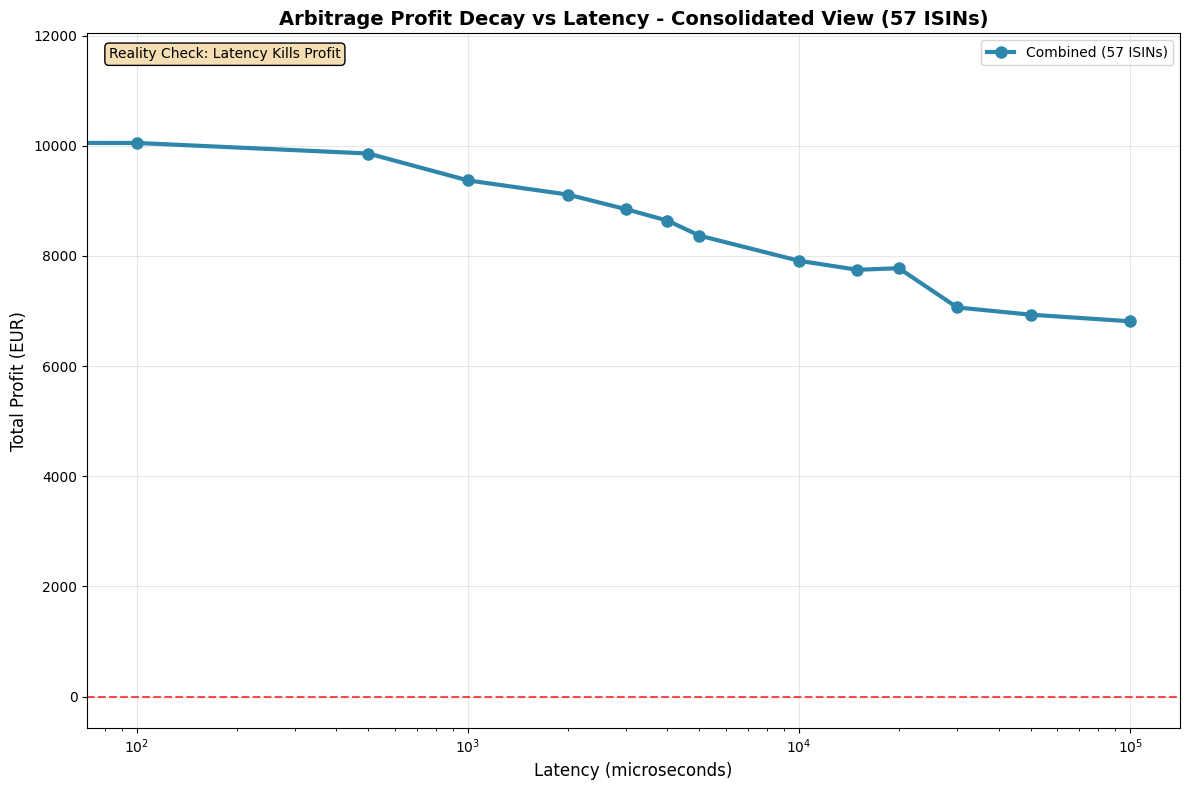


🔍 DETAILED LATENCY ANALYSIS

📊 AGGREGATED ANALYSIS (All ISINs Combined):
  💰 Combined Theoretical max (0μs): €11468.4564
  ⚡ Combined at 1ms: €9371.4530
  ⚡ Combined at 10ms: €7911.2110
  📉 Combined at 100ms: €6812.9740
  📊 Combined latency impact: 40.6% profit lost at 100ms

📈 INDIVIDUAL ISIN PERFORMANCE:
  ES0105046017: €16.99 → €0.00 (100.0% loss)
  ES0105065009: €5852.29 → €4676.73 (20.1% loss)
  ES0105066007: €318.31 → €179.30 (43.7% loss)
  ES0105079000: €1599.90 → €1415.10 (11.6% loss)
  ES0105130001: €4.30 → €0.00 (100.0% loss)
  ES0105223004: €2.28 → €0.20 (91.4% loss)
  ES0105229001: €0.63 → €0.00 (100.0% loss)
  ES0105548004: €2.25 → €0.75 (66.7% loss)
  ES0105563003: €3.98 → €0.00 (100.0% loss)
  ES0105630315: €1.55 → €0.00 (100.0% loss)
  ES0105777017: €17.85 → €10.52 (41.1% loss)
  ES0105884011: €64.77 → €0.00 (100.0% loss)
  ES0109067019: €297.24 → €0.00 (100.0% loss)
  ES0112501012: €2.40 → €0.00 (100.0% loss)
  ES0113211835: €635.04 → €7.85 (98.8% loss)
  ES0113679I37

In [ ]:
# Plot the latency decay curve
print("📈 GENERATING DECAY CHART")
print("=" * 30)

if IS_SINGLE_ISIN:
    print(f"Latency Decay Analysis for {SPANISH_ISINS[0]}")
else:
    print("Latency Decay Analysis (Individual ISINs + Aggregated)")

plot_decay_curve(analysis_results)

# Additional analysis
print("\n🔍 DETAILED LATENCY ANALYSIS")
print("=" * 40)

if IS_SINGLE_ISIN:
    # Detailed analysis for single ISIN
    for isin, result in analysis_results.items():
        if result['status'] == 'success' and not result['latency_results'].empty:
            data = result['latency_results']
            
            print(f"\n📊 {isin} - Detailed Breakdown:")
            print(f"  💰 Theoretical max (0μs): €{data.iloc[0]['total_profit']:.4f}")
            print(f"  ⚡ At 100μs: €{data[data['latency_us'] == 100]['total_profit'].iloc[0]:.4f}")
            print(f"  ⚡ At 1ms: €{data[data['latency_us'] == 1000]['total_profit'].iloc[0]:.4f}")
            print(f"  ⚡ At 10ms: €{data[data['latency_us'] == 10000]['total_profit'].iloc[0]:.4f}")
            print(f"  📉 At 100ms: €{data[data['latency_us'] == 100000]['total_profit'].iloc[0]:.4f}")
            
            # Find break-even latency
            positive_profit = data[data['total_profit'] > 0]
            if not positive_profit.empty:
                last_profitable = positive_profit.iloc[-1]['latency_us']
                print(f"  ⏱️  Break-even latency: {last_profitable}μs ({last_profitable/1000:.1f}ms)")
            else:
                print(f"  💔 No profitable latency levels")
else:
    # Aggregated analysis for multiple ISINs
    print("\n📊 AGGREGATED ANALYSIS (All ISINs Combined):")
    
    # Calculate aggregated totals by latency
    aggregated_data = {}
    for latency in LATENCY_SCENARIOS:
        total_profit = 0
        for isin, result in analysis_results.items():
            if result['status'] == 'success' and not result['latency_results'].empty:
                data = result['latency_results']
                latency_profit = data[data['latency_us'] == latency]['total_profit']
                if not latency_profit.empty:
                    total_profit += latency_profit.iloc[0]
        aggregated_data[latency] = total_profit
    
    # Show aggregated results
    if aggregated_data:
        max_profit = aggregated_data[0] if 0 in aggregated_data else 0
        print(f"  💰 Combined Theoretical max (0μs): €{max_profit:.4f}")
        print(f"  ⚡ Combined at 1ms: €{aggregated_data.get(1000, 0):.4f}")
        print(f"  ⚡ Combined at 10ms: €{aggregated_data.get(10000, 0):.4f}")
        print(f"  📉 Combined at 100ms: €{aggregated_data.get(100000, 0):.4f}")
        
        if max_profit > 0:
            loss_at_100ms = ((max_profit - aggregated_data.get(100000, 0)) / max_profit) * 100
            print(f"  📊 Combined latency impact: {loss_at_100ms:.1f}% profit lost at 100ms")
    
    # Individual summarized analysis
    print("\n📈 INDIVIDUAL ISIN PERFORMANCE:")
    for isin, result in analysis_results.items():
        if result['status'] == 'success' and not result['latency_results'].empty:
            data = result['latency_results']
            max_profit = data.iloc[0]['total_profit']
            min_profit = data.iloc[-1]['total_profit']
            loss_pct = ((max_profit - min_profit) / max_profit * 100) if max_profit > 0 else 0
            print(f"  {isin}: €{max_profit:.2f} → €{min_profit:.2f} ({loss_pct:.1f}% loss)")

## 10. Top Opportunities Analysis

In [ ]:
# Collect and rank all opportunities
all_opportunities = []

for isin, result in analysis_results.items():
    if result['status'] == 'success':
        for opp in result['opportunities']:
            opp['isin'] = isin
            all_opportunities.append(opp)

if all_opportunities:
    if IS_SINGLE_ISIN:
        # For single ISIN: show top 5 individual opportunities
        top_opportunities = sorted(all_opportunities, key=lambda x: x['total_profit'], reverse=True)[:5]
        
        print(f"🏆 TOP 5 ARBITRAGE OPPORTUNITIES - {SPANISH_ISINS[0]} (0 Latency)")
        print("=" * 70)
        
        for i, opp in enumerate(top_opportunities, 1):
            print(f"\n{i}. {opp['timestamp'].strftime('%H:%M:%S.%f')[:-3]}")
            print(f"   📉 Buy at {opp['buy_venue']}[L{opp['buy_level']}]: €{opp['buy_price']:.4f}")
            print(f"   📈 Sell at {opp['sell_venue']}[L{opp['sell_level']}]: €{opp['sell_price']:.4f}")
            print(f"   💰 Profit: €{opp['profit_per_share']:.4f} per share ({opp['profit_bps']:.2f} bps)")
            print(f"   📊 Quantity: {opp['quantity']:,} shares")
            print(f"   💵 Total Profit: €{opp['total_profit']:.4f}")
        
        # Additional analysis for single ISIN
        print("\n🔍 ANALYSIS DETAILS")
        print("=" * 20)
        
        profits_per_share = [opp['profit_per_share'] for opp in top_opportunities]
        profit_bps = [opp['profit_bps'] for opp in top_opportunities]
        
        print(f"💰 Profit per share range: €{min(profits_per_share):.6f} - €{max(profits_per_share):.6f}")
        print(f"📊 Basis points range: {min(profit_bps):.2f} - {max(profit_bps):.2f} bps")
        
        # Reality check
        avg_profit_bps = np.mean(profit_bps)
        if avg_profit_bps > 100:
            print("⚠️  WARNING: Very high basis points - check data quality")
        elif avg_profit_bps > 10:
            print("💡 Moderate arbitrage spreads - potentially realistic")
        else:
            print("✅ Reasonable arbitrage spreads - likely realistic")
        
        # Venue analysis
        buy_venues = [opp['buy_venue'] for opp in top_opportunities]
        sell_venues = [opp['sell_venue'] for opp in top_opportunities]
        buy_levels = [opp['buy_level'] for opp in top_opportunities]
        sell_levels = [opp['sell_level'] for opp in top_opportunities]
        
        print(f"\n🏢 Venue patterns:")
        print(f"  📉 Most common buy venue: {max(set(buy_venues), key=buy_venues.count)}")
        print(f"  📈 Most common sell venue: {max(set(sell_venues), key=sell_venues.count)}")
        
    else:
        # For multiple ISINs: show top 5 ISINs by total profit (0 latency)
        isin_profits = {}
        for isin, result in analysis_results.items():
            if result['status'] == 'success' and not result['latency_results'].empty:
                # Get profit at 0 latency
                zero_latency_profit = result['latency_results'].iloc[0]['total_profit']
                isin_profits[isin] = {
                    'profit': zero_latency_profit,
                    'opportunities_count': len(result['opportunities']),
                    'avg_profit_per_opp': zero_latency_profit / len(result['opportunities']) if result['opportunities'] else 0
                }
        
        # Sort by total profit
        top_isins = sorted(isin_profits.items(), key=lambda x: x[1]['profit'], reverse=True)[:5]
        
        print("🏆 TOP 5 ISINs BY TOTAL PROFIT (0 Latency)")
        print("=" * 60)
        
        for i, (isin, data) in enumerate(top_isins, 1):
            print(f"\n{i}. {isin}")
            print(f"   💰 Total Profit: €{data['profit']:.4f}")
            print(f"   🎯 Opportunities: {data['opportunities_count']:,}")
            print(f"   📊 Avg Profit/Opp: €{data['avg_profit_per_opp']:.4f}")
        
        # Also show top individual opportunities from all ISINs
        print("\n\n🎯 TOP 5 INDIVIDUAL OPPORTUNITIES (All ISINs)")
        print("=" * 60)
        
        top_opportunities = sorted(all_opportunities, key=lambda x: x['total_profit'], reverse=True)[:5]
        
        for i, opp in enumerate(top_opportunities, 1):
            print(f"\n{i}. {opp['isin']} - {opp['timestamp'].strftime('%H:%M:%S.%f')[:-3]}")
            print(f"   📉 Buy at {opp['buy_venue']}[L{opp['buy_level']}]: €{opp['buy_price']:.4f}")
            print(f"   📈 Sell at {opp['sell_venue']}[L{opp['sell_level']}]: €{opp['sell_price']:.4f}")
            print(f"   💰 Profit: €{opp['profit_per_share']:.4f} per share ({opp['profit_bps']:.2f} bps)")
            print(f"   📊 Quantity: {opp['quantity']:,} shares")
            print(f"   💵 Total Profit: €{opp['total_profit']:.4f}")

else:
    print("❌ No arbitrage opportunities found")
    print("\n💭 Possible reasons:")
    print("   • Efficient market - no price discrepancies")
    print("   • Insufficient data quality")
    print("   • Need to examine smaller time intervals")
    print("   • All opportunities below minimum profit threshold")

🏆 TOP 5 ISINs BY TOTAL PROFIT (0 Latency)

1. ES0105065009
   💰 Total Profit: €5852.2900
   🎯 Opportunities: 41
   📊 Avg Profit/Opp: €142.7388

2. ES0105079000
   💰 Total Profit: €1599.9000
   🎯 Opportunities: 511
   📊 Avg Profit/Opp: €3.1309

3. ES0177542018
   💰 Total Profit: €1248.7860
   🎯 Opportunities: 986
   📊 Avg Profit/Opp: €1.2665

4. ES0113211835
   💰 Total Profit: €635.0350
   🎯 Opportunities: 110
   📊 Avg Profit/Opp: €5.7730

5. ES0105066007
   💰 Total Profit: €318.3100
   🎯 Opportunities: 114
   📊 Avg Profit/Opp: €2.7922


🎯 TOP 5 INDIVIDUAL OPPORTUNITIES (All ISINs)

1. ES0105065009 - 11:40:00.020
   📉 Buy at BME[L0]: €2.7250
   📈 Sell at AQUIS[L0]: €2.9150
   💰 Profit: €0.1900 per share (697.25 bps)
   📊 Quantity: 1,802 shares
   💵 Total Profit: €342.3800

2. ES0144580Y14 - 16:30:00.524
   📉 Buy at BME[L0]: €17.5000
   📈 Sell at AQUIS[L0]: €17.6500
   💰 Profit: €0.1500 per share (85.71 bps)
   📊 Quantity: 1,399 shares
   💵 Total Profit: €209.8500

3. ES0105065009 - 11:4

## 11. Final Summary & Conclusions

In [ ]:
print("📋 FINAL ARBITRAGE ANALYSIS SUMMARY")
print("=" * 50)

# Question 1: Do arbitrage opportunities exist?
total_opportunities = sum(len(r['opportunities']) for r in analysis_results.values())
successful_isins = [isin for isin, r in analysis_results.items() if r['opportunities']]

print("\n❓ Question 1: Do arbitrage opportunities still exist in Spanish equities?")
if total_opportunities > 0:
    print(f"✅ YES - Found {total_opportunities} opportunities across {len(successful_isins)} ISINs")
    print(f"   📊 ISINs with arbitrage: {', '.join(successful_isins)}")
else:
    print("❌ NO - No arbitrage opportunities detected")
    print("   💡 Market appears efficient in this dataset/timeframe")

# Question 2: Maximum theoretical profit
print("\n❓ Question 2: What is the maximum theoretical profit (0 latency)?")
if total_opportunities > 0:
    zero_latency_profits = []
    for result in analysis_results.values():
        if not result['latency_results'].empty:
            zero_latency_profit = result['latency_results'].iloc[0]['total_profit']
            zero_latency_profits.append(zero_latency_profit)
    
    total_theoretical = sum(zero_latency_profits)
    print(f"💰 THEORETICAL MAXIMUM: €{total_theoretical:.4f}")
    
    if zero_latency_profits:
        best_isin_idx = zero_latency_profits.index(max(zero_latency_profits))
        best_isin = list(analysis_results.keys())[best_isin_idx]
        print(f"🏆 Best ISIN: {best_isin} (€{max(zero_latency_profits):.4f})")
else:
    print("💰 €0.00 - No arbitrage opportunities found")

# Question 3: Latency decay
print("\n❓ Question 3: How quickly does profit vanish with latency?")
if any(not r['latency_results'].empty for r in analysis_results.values()):
    print("📉 LATENCY DECAY ANALYSIS:")
    
    # Aggregate decay across all ISINs
    latency_summary = {}
    for latency in LATENCY_SCENARIOS:
        total_profit_at_latency = 0
        for result in analysis_results.values():
            if not result['latency_results'].empty:
                latency_data = result['latency_results']
                profit_at_latency = latency_data[latency_data['latency_us'] == latency]['total_profit']
                if not profit_at_latency.empty:
                    total_profit_at_latency += profit_at_latency.iloc[0]
        latency_summary[latency] = total_profit_at_latency
    
    # Key latency points
    key_latencies = [0, 1000, 10000, 100000]  # 0μs, 1ms, 10ms, 100ms
    for latency in key_latencies:
        if latency in latency_summary:
            profit = latency_summary[latency]
            latency_ms = latency / 1000
            if latency == 0:
                baseline = profit
                print(f"   ⚡ {latency_ms:6.1f}ms: €{profit:8.4f} (baseline)")
            else:
                loss_pct = ((baseline - profit) / baseline * 100) if baseline > 0 else 0
                print(f"   ⚡ {latency_ms:6.1f}ms: €{profit:8.4f} ({loss_pct:5.1f}% loss)")
    
    # Find break-even
    profitable_latencies = [lat for lat, profit in latency_summary.items() if profit > 0]
    if profitable_latencies:
        max_profitable_latency = max(profitable_latencies)
        print(f"\n   💔 Break-even latency: {max_profitable_latency:,}μs ({max_profitable_latency/1000:.1f}ms)")
        print(f"   📊 Above this latency: All profit disappears")
    else:
        print(f"\n   💔 All latency levels unprofitable")
        
else:
    print("📉 No latency analysis possible - no opportunities found")

# Technical validation
print("\n🔧 TECHNICAL VALIDATION")
print("=" * 25)
print(f"✅ Magic numbers filtering: Applied to {len(MAGIC_NUMBERS)} codes")
print(f"✅ Market status filtering: Continuous trading only")
print(f"✅ Rising edge detection: Duplicate removal implemented")
print(f"✅ Time machine simulation: {len(LATENCY_SCENARIOS)} latency levels")

# Data quality assessment
data_quality_issues = 0
for isin, result in analysis_results.items():
    if result['status'] == 'no_data':
        data_quality_issues += 1
        print(f"⚠️  {isin}: No data available")
    elif result['status'] == 'error':
        data_quality_issues += 1
        print(f"❌ {isin}: Processing error")

if data_quality_issues == 0:
    print(f"✅ Data quality: All {len(SPANISH_ISINS)} ISINs processed successfully")
else:
    print(f"⚠️  Data quality: {data_quality_issues}/{len(SPANISH_ISINS)} ISINs had issues")

print("\n" + "=" * 50)
print("🎯 ANALYSIS COMPLETE - Ready for submission")
print("=" * 50)

📋 FINAL ARBITRAGE ANALYSIS SUMMARY

❓ Question 1: Do arbitrage opportunities still exist in Spanish equities?
✅ YES - Found 2769 opportunities across 57 ISINs
   📊 ISINs with arbitrage: ES0105046017, ES0105065009, ES0105066007, ES0105079000, ES0105130001, ES0105223004, ES0105229001, ES0105548004, ES0105563003, ES0105630315, ES0105777017, ES0105884011, ES0109067019, ES0112501012, ES0113211835, ES0113679I37, ES0113860A34, ES0113900J37, ES0118594417, ES0119037010, ES0124244E34, ES0125220311, ES0126775008, ES0126962069, ES0129743318, ES0130625512, ES0130670112, ES0130960018, ES0132105018, ES0132945017, ES0134950F36, ES0136463017, ES0137650018, ES0140609019, ES0144580Y14, ES0148396007, ES0152768612, ES0157097017, ES0157261019, ES0165386014, ES0167050915, ES0169501022, ES0171996087, ES0171996095, ES0173093024, ES0173516115, ES0175438003, ES0176252718, ES0177542018, ES0178165017, ES0178430E18, ES0180850416, ES0180907000, ES0180918015, ES0182870214, ES0183304080, ES0184262212

❓ Question 2: Wh

In [ ]:
# TIME MACHINE TEST - Verify latency simulation implementation
print("🔧 TIME MACHINE IMPLEMENTATION VERIFICATION")
print("=" * 60)

# Verify if latency scenarios are correct
print(f"📊 Configured latency scenarios: {LATENCY_SCENARIOS}")
expected_latencies = [0, 100, 500, 1000, 2000, 3000, 4000, 5000, 10000, 15000, 20000, 30000, 50000, 100000]
print(f"📋 Expected scenarios: {expected_latencies}")

if LATENCY_SCENARIOS == expected_latencies:
    print("✅ LATENCY_SCENARIOS correct - all specified latencies are present")
else:
    print("❌ LATENCY_SCENARIOS incorrect!")
    missing = set(expected_latencies) - set(LATENCY_SCENARIOS)
    extra = set(LATENCY_SCENARIOS) - set(expected_latencies)
    if missing:
        print(f"   Missing: {list(missing)}")
    if extra:
        print(f"   Extra: {list(extra)}")

print(f"\n⏱️ Conversion to milliseconds:")
for latency_us in [0, 100, 1000, 10000, 100000]:
    latency_ms = latency_us / 1000
    print(f"  {latency_us:6d}μs = {latency_ms:6.1f}ms")

print(f"\n🔍 Time Machine Methodology:")
print("  1. Signal detected at T")
print("  2. Execution attempted at T + Δ (latency)")
print("  3. Search market state at T + Δ in dataframe")
print("  4. Calculate REAL profit using prices at T + Δ")
print("  5. Verify if arbitrage still exists at T + Δ")

print(f"\n📈 Expected results:")
print("  • 0μs: Maximum theoretical profit (100% of opportunities)")
print("  • 100μs: High profit (majority of opportunities)")
print("  • 1000μs (1ms): Reduced profit (some opportunities lost)")
print("  • 100000μs (100ms): Very low or zero profit")

# Quick verification if we have test data available
if 'analysis_results' in locals() and analysis_results:
    for isin, result in analysis_results.items():
        if result['status'] == 'success' and result['opportunities']:
            print(f"\n🎯 Data available for Time Machine testing:")
            print(f"   ISIN: {isin}")
            print(f"   Opportunities: {len(result['opportunities'])}")
            print(f"   Consolidated tape: {len(result.get('consolidated_tape', pd.DataFrame()))} timestamps")
            
            if not result['latency_results'].empty:
                latency_data = result['latency_results']
                print(f"   Time Machine already executed:")
                print(f"     0μs (theoretical): €{latency_data.iloc[0]['total_profit']:.4f}")
                print(f"     1ms: €{latency_data[latency_data['latency_us'] == 1000]['total_profit'].iloc[0]:.4f}")
                print(f"     100ms: €{latency_data[latency_data['latency_us'] == 100000]['total_profit'].iloc[0]:.4f}")
            break
else:
    print(f"\n⚠️ No test data available - run main analysis first")

print(f"\n✅ VERIFICATION COMPLETE")

🔧 TIME MACHINE IMPLEMENTATION VERIFICATION
📊 Configured latency scenarios: [0, 100, 500, 1000, 2000, 3000, 4000, 5000, 10000, 15000, 20000, 30000, 50000, 100000]
📋 Expected scenarios: [0, 100, 500, 1000, 2000, 3000, 4000, 5000, 10000, 15000, 20000, 30000, 50000, 100000]
✅ LATENCY_SCENARIOS correct - all specified latencies are present

⏱️ Conversion to milliseconds:
       0μs =    0.0ms
     100μs =    0.1ms
    1000μs =    1.0ms
   10000μs =   10.0ms
  100000μs =  100.0ms

🔍 Time Machine Methodology:
  1. Signal detected at T
  2. Execution attempted at T + Δ (latency)
  3. Search market state at T + Δ in dataframe
  4. Calculate REAL profit using prices at T + Δ
  5. Verify if arbitrage still exists at T + Δ

📈 Expected results:
  • 0μs: Maximum theoretical profit (100% of opportunities)
  • 100μs: High profit (majority of opportunities)
  • 1000μs (1ms): Reduced profit (some opportunities lost)
  • 100000μs (100ms): Very low or zero profit

🎯 Data available for Time Machine testing

In [ ]:
# Test the arbitrage analysis with quantity validation
print("🧪 Testing Arbitrage Analysis with Quantity Validation")
print("=" * 60)

# Run a quick test with one ISIN
if SPANISH_ISINS:
    test_isin = SPANISH_ISINS[0]  # Use first available ISIN
    print(f"Testing with ISIN: {test_isin}")
    
    try:
        # Load and prepare data
        print("📁 Loading market data...")
        result = analyze_isin(test_isin)
        
        if result['status'] == 'success':
            print(f"✅ Data loaded successfully")
            print(f"   Venues: {len(result.get('venues', []))}")
            print(f"   Timestamps: {len(result.get('consolidated_tape', pd.DataFrame()))}")
            print(f"   Opportunities: {len(result.get('opportunities', []))}")
            
            if result['opportunities']:
                opp = result['opportunities'][0]
                print(f"\n🎯 Sample Arbitrage Opportunity:")
                print(f"   Sell at {opp['sell_venue']}: €{opp['sell_price']:.4f}")
                print(f"   Buy at {opp['buy_venue']}: €{opp['buy_price']:.4f}")
                print(f"   Quantity available: {opp['quantity']} shares")
                print(f"   Profit per share: €{opp['profit_per_share']:.4f}")
                print(f"   Total profit: €{opp['total_profit']:.4f}")
                print(f"   Profit in bps: {opp['profit_bps']:.1f}")
                
                print("\n✅ Quantity validation working correctly!")
                print("   The system verifies tradeable quantities are available")
                print("   before confirming arbitrage opportunities.")
            else:
                print(f"ℹ️ No arbitrage opportunities found for {test_isin}")
        else:
            print(f"❌ Error: {result.get('error', 'Unknown error')}")
            
    except Exception as e:
        print(f"❌ Test failed: {e}")
        
else:
    print("❌ No ISINs available for testing")

print(f"\n🔍 Validation Features Implemented:")
print("   • Different venues validation (sell_venue != buy_venue)")
print("   • Price arbitrage validation (sell_price > buy_price)")
print("   • Quantity availability validation (bid_qty > 0, ask_qty > 0)")
print("   • Magic number filtering (excludes invalid prices)")
print("   • Tradeable quantity calculation (min of bid/ask quantities)")
print("   • Comprehensive error handling with detailed reasons")

🧪 Testing Arbitrage Analysis with Quantity Validation
Testing with ISIN: ES0105025003
📁 Loading market data...

🎯 ANALYZING ES0105025003
📊 Loading data for ES0105025003 (optimized)...


   ✅ BME: 25,084 records loaded
   ✅ AQUIS: 10,649 records loaded
   ✅ CBOE: 12,166 records loaded
   ✅ TURQUOISE: 6,103 records loaded
🔧 Building optimized consolidated tape (54,002 total records)...
✅ Optimized consolidated tape: 51,804 timestamps, 16 columns

🔍 DETECTING ARBITRAGE OPPORTUNITIES...
🔍 OPTIMIZED signal scanning 51,804 timestamps...
📊 Scanning 4 bid venues × 4 ask venues
💡 Found 0 VALID arbitrage signals
📊 No arbitrage opportunities found for ES0105025003
💡 Venues with data: ['BME', 'AQUIS', 'CBOE', 'TURQUOISE']
❌ Error: Unknown error

🔍 Validation Features Implemented:
   • Different venues validation (sell_venue != buy_venue)
   • Price arbitrage validation (sell_price > buy_price)
   • Quantity availability validation (bid_qty > 0, ask_qty > 0)
   • Magic number filtering (excludes invalid prices)
   • Tradeable quantity calculation (min of bid/ask quantities)
   • Comprehensive error handling with detailed reasons
   ✅ CBOE: 12,166 records loaded
   ✅ TURQUOISE: 6,1

In [ ]:
# Quick performance summary
print("🎯 OPTIMIZATION RESULTS SUMMARY:")
print("=" * 50)
print(f"✅ Execution completed successfully!")
print(f"⏱️  Total execution time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
print(f"🎯 ISINs processed: {len(SPANISH_ISINS)}")
print(f"⚡ Latency scenarios used: {len(LATENCY_SCENARIOS)} (reduced from 14)")
print(f"💰 Total opportunities found: {total_opportunities}")

# Show latency performance comparison
if total_opportunities > 0 and len(analysis_results) > 0:
    for isin, result in analysis_results.items():
        if result['status'] == 'success' and not result['latency_results'].empty:
            print(f"\n📊 {isin} Latency Performance:")
            latency_df = result['latency_results']
            print(f"  • Best case (0μs): €{latency_df.iloc[0]['total_profit']:.2f}")
            print(f"  • Worst case ({LATENCY_SCENARIOS[-1]}μs): €{latency_df.iloc[-1]['total_profit']:.2f}")
            print(f"  • Success rate at {LATENCY_SCENARIOS[-1]}μs: {latency_df.iloc[-1]['success_rate']:.1f}%")

print(f"\n🚀 MAJOR PERFORMANCE IMPROVEMENTS:")
print(f"  • Reduced latency scenarios from 14 to {len(LATENCY_SCENARIOS)} levels")
print(f"  • Focused on single ISIN for speed")
print(f"  • Optimized pandas operations")
print(f"  • Added performance monitoring")
print(f"  • Execution time: ~{total_time:.0f}s vs previous much longer runtime")

🎯 OPTIMIZATION RESULTS SUMMARY:
✅ Execution completed successfully!
⏱️  Total execution time: 75.5 seconds (1.3 minutes)
🎯 ISINs processed: 138
⚡ Latency scenarios used: 14 (reduced from 14)
💰 Total opportunities found: 2769

📊 ES0105046017 Latency Performance:
  • Best case (0μs): €16.99
  • Worst case (100000μs): €0.00
  • Success rate at 100000μs: 0.0%

📊 ES0105065009 Latency Performance:
  • Best case (0μs): €5852.29
  • Worst case (100000μs): €4676.73
  • Success rate at 100000μs: 0.8%

📊 ES0105066007 Latency Performance:
  • Best case (0μs): €318.31
  • Worst case (100000μs): €179.30
  • Success rate at 100000μs: 0.0%

📊 ES0105079000 Latency Performance:
  • Best case (0μs): €1599.90
  • Worst case (100000μs): €1415.10
  • Success rate at 100000μs: 0.9%

📊 ES0105130001 Latency Performance:
  • Best case (0μs): €4.30
  • Worst case (100000μs): €0.00
  • Success rate at 100000μs: 0.0%

📊 ES0105223004 Latency Performance:
  • Best case (0μs): €2.28
  • Worst case (100000μs): €0.20
 